<a href="https://colab.research.google.com/github/JSEFERINO/Analisis-de-Datos-con-Python-2020/blob/master/Laboratorio6_JersonDiaz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 6 - Intervalos  de Confianza**
# **Estadistica inferencial**
## **Jerson David Díaz Alvarez**
> Email: djerson347@gmail.com

> Celular: 3146713674

> Código Estudiantil: T00070477

#**Taller: Intervalos de Confianza para la Media en R**

##**Objetivos**


*   Comprender qué es un intervalo de confianza y su interpretación.

*   Calcular intervalos de confianza para la media con varianza conocida y desconocida.

*   Calcular intervalos de confianza para diferentes niveles de confianza.

### **Ejercicio 1: Intervalo de Confianza para la Media (Varianza Conocida)**
Cuando la varianza de la población es conocida, usamos la distribución normal para calcular el intervalo de confianza.

***Datos: Supón que tienes una muestra de 30 estudiantes con puntuaciones en un examen, y conoces la desviación estándar de la población que es 15. Calcula el intervalo de confianza del 95% para la media de la muestra.***



# **Librerias para Trabar en R**

In [ ]:
# @title **Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

<a name="inicio"></a>


## **1.** [Problema 1](#T1)
## **2.** [Graficar la distribución normal y el intervalo de confianza](#T2)
## **3.** [Problema 1 en Python](#T3)

## **4.** [Problema 2](#T4)
## **5.** [Graficar la distribución normal y el intervalo de confianza](#T5)
## **6.** [Problema 2 en Python](#T6)

## **7.** [Problema 3](#T7)
## **8.** [Graficar la distribución normal y el intervalo de confianza](#T8)
## **9.** [Problema 3 en Python](#T9)

## **10.** [Problema 4](#T10)
## **11.** [Graficar la distribución normal y el intervalo de confianza](#T11)
## **12.** [Problema 4 en Python](#T12)




[ULTIMO](#ULTIMO)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Problema 1**
***Datos: Supón que tienes una muestra de 30 estudiantes con puntuaciones en un examen, y conoces la desviación estándar de la población que es 15. Calcula el intervalo de confianza del 95% para la media de la muestra, conociendo que la muestra tiene una media de 75.***




In [ ]:
# @title Parámetros conocidos
%%R
media_muestra <- 75  # Media de la muestra
sigma <- 15          # Desviación estándar de la población
n <- 30              # Tamaño de la muestra
nivel_confianza <- 0.95

# Cálculo del error estándar
error_estandar <- sigma / sqrt(n)

# Valor z crítico
z_critico <- qnorm(1 - (1 - nivel_confianza) / 2)

# Intervalo de confianza
limite_inferior <- media_muestra - z_critico * error_estandar
limite_superior <- media_muestra + z_critico * error_estandar

cat("El intervalo de confianza del 95% para la media es: [", limite_inferior, ",", limite_superior, "]\n")

El intervalo de confianza del 95% para la media es: [ 69.63242 , 80.36758 ]


[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Graficar la distribución normal y el intervalo de confianza**
***


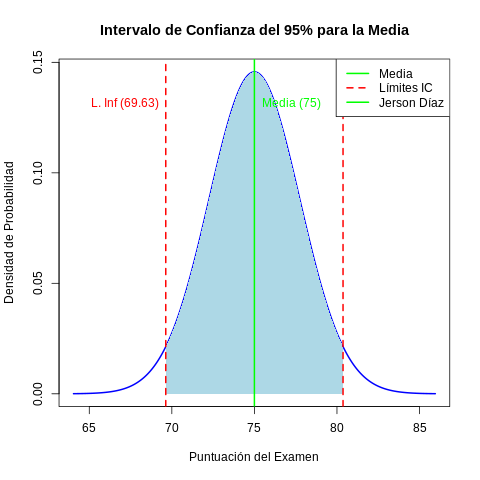

In [ ]:
%%R


# Crear una secuencia de valores x para la distribución normal
x <- seq(media_muestra - 4 * error_estandar, media_muestra + 4 * error_estandar, length.out = 500)

# Calcular la densidad de probabilidad para cada x
y <- dnorm(x, mean = media_muestra, sd = error_estandar)

# Crear el gráfico
plot(x, y, type = "l", col = "blue", lwd = 2, xlab = "Puntuación del Examen", ylab = "Densidad de Probabilidad",
     main = "Intervalo de Confianza del 95% para la Media")

# Sombrear el área del intervalo de confianza
polygon(c(limite_inferior, x[x >= limite_inferior & x <= limite_superior], limite_superior),
        c(0, y[x >= limite_inferior & x <= limite_superior], 0),
        col = "lightblue", border = NA)

# Añadir líneas verticales para los límites del intervalo y la media
abline(v = limite_inferior, col = "red", lty = 2, lwd = 2)
abline(v = limite_superior, col = "red", lty = 2, lwd = 2)
abline(v = media_muestra, col = "green", lty = 1, lwd = 2)

# Añadir texto al gráfico
text(media_muestra, max(y) * 0.9, "Media (75)", col = "green", pos = 4)
text(limite_inferior, max(y) * 0.9, paste0("L. Inf (", round(limite_inferior, 2), ")"), col = "red", pos = 2)
text(limite_superior, max(y) * 0.9, paste0("L. Sup (", round(limite_superior, 2), ")"), col = "red", pos = 4)

legend("topright", legend = c("Media", "Límites IC", "Jerson Díaz"), col = c("green", "red"), lty = c(1, 2), lwd = 2)


[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. Problema 1 en Python**


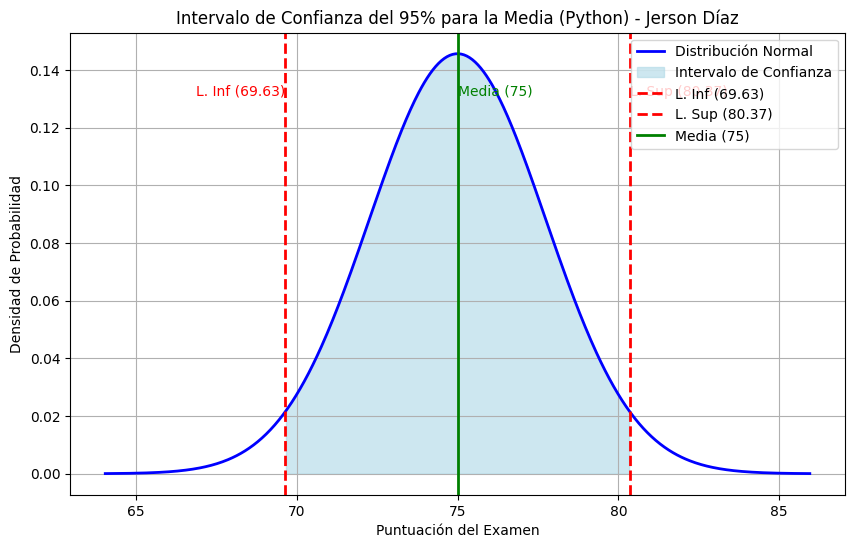

In [ ]:
 import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros conocidos (re-definiendo para el bloque Python, asegurando que estén disponibles)
media_muestra = 75  # Media de la muestra
sigma = 15          # Desviación estándar de la población
n = 30              # Tamaño de la muestra
nivel_confianza = 0.95

# Cálculo del error estándar
error_estandar = sigma / np.sqrt(n)

# Valor z crítico
z_critico = norm.ppf(1 - (1 - nivel_confianza) / 2)

# Intervalo de confianza
limite_inferior = media_muestra - z_critico * error_estandar
limite_superior = media_muestra + z_critico * error_estandar

# Crear una secuencia de valores x para la distribución normal
x = np.linspace(media_muestra - 4 * error_estandar, media_muestra + 4 * error_estandar, 500)

# Calcular la densidad de probabilidad para cada x
y = norm.pdf(x, loc=media_muestra, scale=error_estandar)

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(x, y, color='blue', linewidth=2, label='Distribución Normal')

# Sombrear el área del intervalo de confianza
x_fill = x[(x >= limite_inferior) & (x <= limite_superior)]
y_fill = y[(x >= limite_inferior) & (x <= limite_superior)]
plt.fill_between(x_fill, 0, y_fill, color='lightblue', alpha=0.6, label='Intervalo de Confianza')

# Añadir líneas verticales para los límites del intervalo y la media
plt.axvline(limite_inferior, color='red', linestyle='--', linewidth=2, label=f'L. Inf ({limite_inferior:.2f})')
plt.axvline(limite_superior, color='red', linestyle='--', linewidth=2, label=f'L. Sup ({limite_superior:.2f})')
plt.axvline(media_muestra, color='green', linestyle='-', linewidth=2, label=f'Media ({media_muestra})')

# Añadir texto al gráfico
plt.text(media_muestra, np.max(y) * 0.9, f'Media ({media_muestra})', color='green', ha='left')
plt.text(limite_inferior, np.max(y) * 0.9, f'L. Inf ({limite_inferior:.2f})', color='red', ha='right')
plt.text(limite_superior, np.max(y) * 0.9, f'L. Sup ({limite_superior:.2f})', color='red', ha='left')

plt.xlabel('Puntuación del Examen')
plt.ylabel('Densidad de Probabilidad')
plt.title('Intervalo de Confianza del 95% para la Media (Python) - Jerson Díaz' )
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. Problema 2**
***Datos: Una muestra de 20 estudiantes tiene una media de 70 y una desviación estándar de 10. Calcula el intervalo de confianza del 95% para la media.***



In [ ]:
# Parámetros desconocidos
%%R
media_muestra <- 70     # Media de la muestra
s <- 10                 # Desviación estándar de la muestra
n <- 20                 # Tamaño de la muestra
nivel_confianza <- 0.95

# Cálculo del error estándar
error_estandar <- s / sqrt(n)

# Valor t crítico
t_critico <- qt(1 - (1 - nivel_confianza) / 2, df = n - 1)

# Intervalo de confianza
limite_inferior <- media_muestra - t_critico * error_estandar
limite_superior <- media_muestra + t_critico * error_estandar

cat("El intervalo de confianza del 95% para la media es: [", limite_inferior, ",", limite_superior, "]\n")

El intervalo de confianza del 95% para la media es: [ 65.31986 , 74.68014 ]


[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Graficar la distribución normal y el intervalo de confianza**

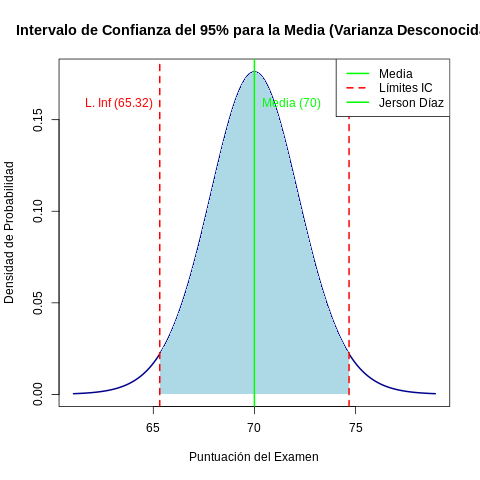

In [ ]:
%%R

# Graficar la distribución t y el intervalo de confianza

# Crear una secuencia de valores x para la distribución t
x_t <- seq(media_muestra - 4 * error_estandar, media_muestra + 4 * error_estandar, length.out = 500)

# Calcular la densidad de probabilidad para cada x usando la distribución t
# Necesitamos transformar x_t a una escala de t-score y luego aplicar dt, escalando por el error estándar
y_t <- dt((x_t - media_muestra) / error_estandar, df = n - 1) / error_estandar

# Crear el gráfico
plot(x_t, y_t, type = "l", col = "darkblue", lwd = 2, xlab = "Puntuación del Examen", ylab = "Densidad de Probabilidad",
     main = "Intervalo de Confianza del 95% para la Media (Varianza Desconocida)")

# Sombrear el área del intervalo de confianza
polygon(c(limite_inferior, x_t[x_t >= limite_inferior & x_t <= limite_superior], limite_superior),
        c(0, y_t[x_t >= limite_inferior & x_t <= limite_superior], 0),
        col = "lightblue", border = NA)

# Añadir líneas verticales para los límites del intervalo y la media
abline(v = limite_inferior, col = "red", lty = 2, lwd = 2)
abline(v = limite_superior, col = "red", lty = 2, lwd = 2)
abline(v = media_muestra, col = "green", lty = 1, lwd = 2)

# Añadir texto al gráfico
text(media_muestra, max(y_t) * 0.9, "Media (70)", col = "green", pos = 4)
text(limite_inferior, max(y_t) * 0.9, paste0("L. Inf (", round(limite_inferior, 2), ")"), col = "red", pos = 2)
text(limite_superior, max(y_t) * 0.9, paste0("L. Sup (", round(limite_superior, 2), ")"), col = "red", pos = 4)

legend("topright", legend = c("Media", "Límites IC", "Jerson Díaz"), col = c("green", "red"), lty = c(1, 2), lwd = 2)


[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. Problema 2 en Python**

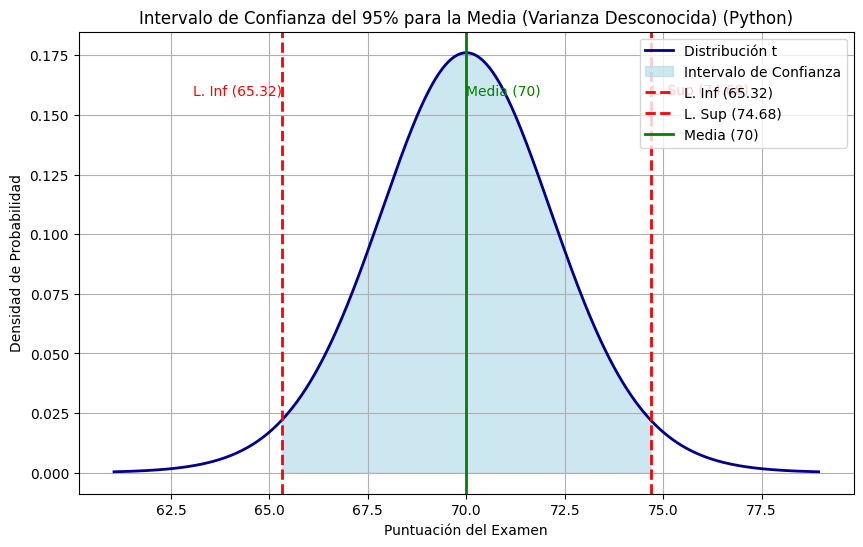

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Parámetros conocidos (re-definiendo para el bloque Python)
media_muestra = 70     # Media de la muestra
s = 10                 # Desviación estándar de la muestra
n = 20                 # Tamaño de la muestra
nivel_confianza = 0.95

# Cálculo del error estándar
error_estandar = s / np.sqrt(n)

# Valor t crítico
t_critico = t.ppf(1 - (1 - nivel_confianza) / 2, df = n - 1)

# Intervalo de confianza
limite_inferior = media_muestra - t_critico * error_estandar
limite_superior = media_muestra + t_critico * error_estandar

# Crear una secuencia de valores x para la distribución t
x_t = np.linspace(media_muestra - 4 * error_estandar, media_muestra + 4 * error_estandar, 500)

# Calcular la densidad de probabilidad para cada x usando la distribución t
y_t = t.pdf(x_t, df = n - 1, loc = media_muestra, scale = error_estandar)

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(x_t, y_t, color='darkblue', linewidth=2, label='Distribución t')

# Sombrear el área del intervalo de confianza
x_fill = x_t[(x_t >= limite_inferior) & (x_t <= limite_superior)]
y_fill = y_t[(x_t >= limite_inferior) & (x_t <= limite_superior)]
plt.fill_between(x_fill, 0, y_fill, color='lightblue', alpha=0.6, label='Intervalo de Confianza')

# Añadir líneas verticales para los límites del intervalo y la media
plt.axvline(limite_inferior, color='red', linestyle='--', linewidth=2, label=f'L. Inf ({limite_inferior:.2f})')
plt.axvline(limite_superior, color='red', linestyle='--', linewidth=2, label=f'L. Sup ({limite_superior:.2f})')
plt.axvline(media_muestra, color='green', linestyle='-', linewidth=2, label=f'Media ({media_muestra})')

# Añadir texto al gráfico
plt.text(media_muestra, np.max(y_t) * 0.9, f'Media ({media_muestra})', color='green', ha='left')
plt.text(limite_inferior, np.max(y_t) * 0.9, f'L. Inf ({limite_inferior:.2f})', color='red', ha='right')
plt.text(limite_superior, np.max(y_t) * 0.9, f'L. Sup ({limite_superior:.2f})', color='red', ha='left')

plt.xlabel('Puntuación del Examen')
plt.ylabel('Densidad de Probabilidad')
plt.title('Intervalo de Confianza del 95% para la Media (Varianza Desconocida) (Python) - Jerson Díaz')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>



## **7. Problema 3**
***Usa los mismos datos del ejercicio 2 para calcular intervalos de confianza del 90%, 95% y 99%.***

In [ ]:
%%R
niveles_confianza <- c(0.90, 0.95, 0.99)

for (nivel in niveles_confianza) {
  t_critico <- qt(1 - (1 - nivel) / 2, df = n - 1)
  limite_inferior <- media_muestra - t_critico * error_estandar
  limite_superior <- media_muestra + t_critico * error_estandar
  cat("El intervalo de confianza del", nivel * 100, "% para la media es: [", limite_inferior, ",", limite_superior, "]\n")
}

El intervalo de confianza del 90 % para la media es: [ 62.77856 , 68.04713 ]
El intervalo de confianza del 95 % para la media es: [ 62.25529 , 68.57039 ]
El intervalo de confianza del 99 % para la media es: [ 61.20196 , 69.62373 ]


[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. Graficar la distribución normal y el intervalo de confianza**

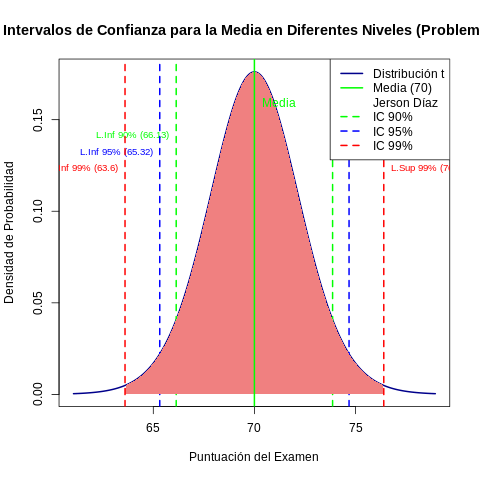

In [ ]:
%%R

# Asegurarse de que las variables media_muestra, s, n, y error_estandar estén definidas
# (ya deberían estarlo si se ejecutaron las celdas del Problema 2)
# Si no, se deberían definir aquí:
# media_muestra <- 70     # Media de la muestra
# s <- 10                 # Desviación estándar de la muestra
# n <- 20                 # Tamaño de la muestra
# error_estandar <- s / sqrt(n)


# Crear una secuencia de valores x para la distribución t
x_t <- seq(media_muestra - 4 * error_estandar, media_muestra + 4 * error_estandar, length.out = 500)

# Calcular la densidad de probabilidad para cada x usando la distribución t
y_t <- dt((x_t - media_muestra) / error_estandar, df = n - 1) / error_estandar

# Iniciar el gráfico base
plot(x_t, y_t, type = "l", col = "darkblue", lwd = 2, xlab = "Puntuación del Examen", ylab = "Densidad de Probabilidad",
     main = "Intervalos de Confianza para la Media en Diferentes Niveles (Problema 3)")

# Definir los niveles de confianza y colores
niveles_confianza <- c(0.90, 0.95, 0.99)
colores_ic <- c("lightgreen", "lightblue", "lightcoral") # Colores para sombrear
colores_lineas <- c("green", "blue", "red") # Colores para los límites

legend_text <- c("Distribución t", paste0("Media (", media_muestra, ")"), "Jerson Díaz")
legend_colors <- c("darkblue", "green", NA)
legend_lty <- c(1, 1, NA)

# Calcular y graficar cada intervalo de confianza
for (i in 1:length(niveles_confianza)) {
  nivel <- niveles_confianza[i]
  color_sombra <- colores_ic[i]
  color_linea <- colores_lineas[i]

  t_critico <- qt(1 - (1 - nivel) / 2, df = n - 1)
  limite_inferior <- media_muestra - t_critico * error_estandar
  limite_superior <- media_muestra + t_critico * error_estandar

  # Sombrear el área del intervalo de confianza
  polygon(c(limite_inferior, x_t[x_t >= limite_inferior & x_t <= limite_superior], limite_superior),
          c(0, y_t[x_t >= limite_inferior & x_t <= limite_superior], 0),
          col = color_sombra, border = NA)

  # Añadir líneas verticales para los límites del intervalo
  abline(v = limite_inferior, col = color_linea, lty = 2, lwd = 2)
  abline(v = limite_superior, col = color_linea, lty = 2, lwd = 2)

  # Añadir el texto del límite al gráfico
  # Ajustar la posición vertical del texto para evitar superposiciones
  text_y_pos_lower = max(y_t) * (0.85 - i * 0.05)
  text_y_pos_upper = max(y_t) * (0.85 - i * 0.05)

  text(limite_inferior, text_y_pos_lower, paste0("L.Inf ", nivel*100, "% (", round(limite_inferior, 2), ")"),
       col = color_linea, pos = 2, cex = 0.8)
  text(limite_superior, text_y_pos_upper, paste0("L.Sup ", nivel*100, "% (", round(limite_superior, 2), ")"),
       col = color_linea, pos = 4, cex = 0.8)

  legend_text <- c(legend_text, paste0("IC ", nivel*100, "%"))
  legend_colors <- c(legend_colors, color_linea)
  legend_lty <- c(legend_lty, 2)
}

# Añadir línea vertical para la media
abline(v = media_muestra, col = "green", lty = 1, lwd = 2)
text(media_muestra, max(y_t) * 0.9, "Media", col = "green", pos = 4)

# Añadir leyenda
legend("topright", legend = legend_text, col = legend_colors, lty = legend_lty, lwd = 2, bg = "white")


[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. Problema 3 en Python**

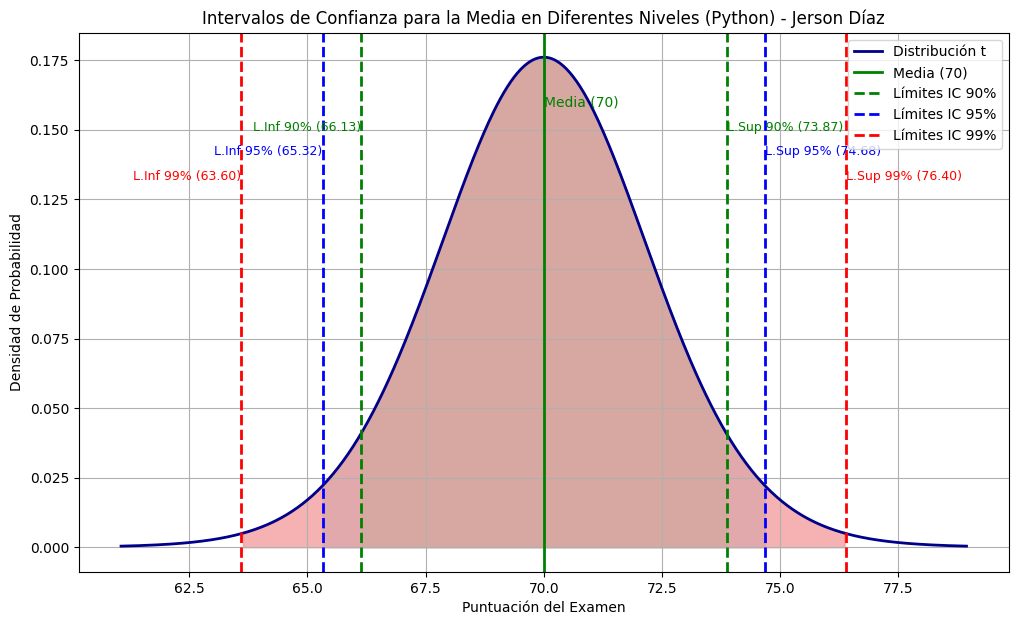

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Parámetros conocidos (re-definiendo para el bloque Python, asegurando que estén disponibles)
media_muestra = 70     # Media de la muestra
s = 10                 # Desviación estándar de la muestra
n = 20                 # Tamaño de la muestra

# Cálculo del error estándar
error_estandar = s / np.sqrt(n)

# Crear una secuencia de valores x para la distribución t
x_t = np.linspace(media_muestra - 4 * error_estandar, media_muestra + 4 * error_estandar, 500)

# Calcular la densidad de probabilidad para cada x usando la distribución t
y_t = t.pdf(x_t, df = n - 1, loc = media_muestra, scale = error_estandar)

# Iniciar el gráfico
plt.figure(figsize=(12, 7))
plt.plot(x_t, y_t, color='darkblue', linewidth=2, label='Distribución t')

# Definir los niveles de confianza y colores
niveles_confianza = [0.90, 0.95, 0.99]
colores_ic = ['lightgreen', 'lightblue', 'lightcoral'] # Colores para sombrear
colores_lineas = ['green', 'blue', 'red'] # Colores para los límites

legend_handles = [plt.Line2D([0], [0], color='darkblue', lw=2, label='Distribución t')]
legend_handles.append(plt.axvline(media_muestra, color='green', linestyle='-', lw=2, label=f'Media ({media_muestra})'))

# Calcular y graficar cada intervalo de confianza
for i, nivel in enumerate(niveles_confianza):
  color_sombra = colores_ic[i]
  color_linea = colores_lineas[i]

  t_critico = t.ppf(1 - (1 - nivel) / 2, df = n - 1)
  limite_inferior = media_muestra - t_critico * error_estandar
  limite_superior = media_muestra + t_critico * error_estandar

  # Sombrear el área del intervalo de confianza
  x_fill = x_t[(x_t >= limite_inferior) & (x_t <= limite_superior)]
  y_fill = y_t[(x_t >= limite_inferior) & (x_t <= limite_superior)]
  plt.fill_between(x_fill, 0, y_fill, color=color_sombra, alpha=0.6, label=f'IC {nivel*100:.0f}%')

  # Añadir líneas verticales para los límites del intervalo
  plt.axvline(limite_inferior, color=color_linea, linestyle='--', linewidth=2)
  plt.axvline(limite_superior, color=color_linea, linestyle='--', linewidth=2)

  # Añadir texto al gráfico
  plt.text(limite_inferior, np.max(y_t) * (0.85 - i * 0.05), f'L.Inf {nivel*100:.0f}% ({limite_inferior:.2f})',
           color=color_linea, ha='right', fontsize=9)
  plt.text(limite_superior, np.max(y_t) * (0.85 - i * 0.05), f'L.Sup {nivel*100:.0f}% ({limite_superior:.2f})',
           color=color_linea, ha='left', fontsize=9)

  legend_handles.append(plt.Line2D([0], [0], color=color_linea, lw=2, ls='--', label=f'Límites IC {nivel*100:.0f}%'))

# Añadir texto para la media
plt.text(media_muestra, np.max(y_t) * 0.9, f'Media ({media_muestra})', color='green', ha='left')

plt.xlabel('Puntuación del Examen')
plt.ylabel('Densidad de Probabilidad')
plt.title('Intervalos de Confianza para la Media en Diferentes Niveles (Python) - Jerson Díaz')
plt.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1.0, 1.0))
plt.grid(True)
plt.show()

[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. Problema 4**
***Genera una muestra aleatoria de datos y calcula el intervalo de confianza para la media.***

In [ ]:
%%R
set.seed(123)  # Fijar la semilla para reproducibilidad
muestra <- rnorm(50, mean = 65, sd = 12)

media_muestra <- mean(muestra)
s <- sd(muestra)
n <- length(muestra)
nivel_confianza <- 0.95

# Cálculo del error estándar y valor t crítico
error_estandar <- s / sqrt(n)
t_critico <- qt(1 - (1 - nivel_confianza) / 2, df = n - 1)

# Intervalo de confianza
limite_inferior <- media_muestra - t_critico * error_estandar
limite_superior <- media_muestra + t_critico * error_estandar

cat("El intervalo de confianza del 95% para la media de la muestra simulada es: [", limite_inferior, ",", limite_superior, "]\n")

El intervalo de confianza del 95% para la media de la muestra simulada es: [ 62.25529 , 68.57039 ]


[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. Graficar la distribución normal y el intervalo de confianza**

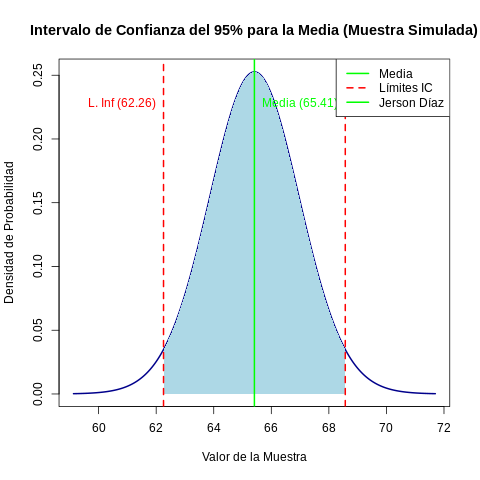

In [ ]:
%%R

# Crear una secuencia de valores x para la distribución t
x_t <- seq(media_muestra - 4 * error_estandar, media_muestra + 4 * error_estandar, length.out = 500)

# Calcular la densidad de probabilidad para cada x usando la distribución t
y_t <- dt((x_t - media_muestra) / error_estandar, df = n - 1) / error_estandar

# Crear el gráfico
plot(x_t, y_t, type = "l", col = "darkblue", lwd = 2, xlab = "Valor de la Muestra", ylab = "Densidad de Probabilidad",
     main = "Intervalo de Confianza del 95% para la Media (Muestra Simulada)")

# Sombrear el área del intervalo de confianza
polygon(c(limite_inferior, x_t[x_t >= limite_inferior & x_t <= limite_superior], limite_superior),
        c(0, y_t[x_t >= limite_inferior & x_t <= limite_superior], 0),
        col = "lightblue", border = NA)

# Añadir líneas verticales para los límites del intervalo y la media
abline(v = limite_inferior, col = "red", lty = 2, lwd = 2)
abline(v = limite_superior, col = "red", lty = 2, lwd = 2)
abline(v = media_muestra, col = "green", lty = 1, lwd = 2)

# Añadir texto al gráfico
text(media_muestra, max(y_t) * 0.9, paste0("Media (", round(media_muestra, 2), ")"), col = "green", pos = 4)
text(limite_inferior, max(y_t) * 0.9, paste0("L. Inf (", round(limite_inferior, 2), ")"), col = "red", pos = 2)
text(limite_superior, max(y_t) * 0.9, paste0("L. Sup (", round(limite_superior, 2), ")"), col = "red", pos = 4)

legend("topright", legend = c("Media", "Límites IC", "Jerson Díaz"), col = c("green", "red"), lty = c(1, 2), lwd = 2)

[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. Problema 4 en Python**

El intervalo de confianza del 95% para la media de la muestra simulada es: [61.0610, 69.2575]


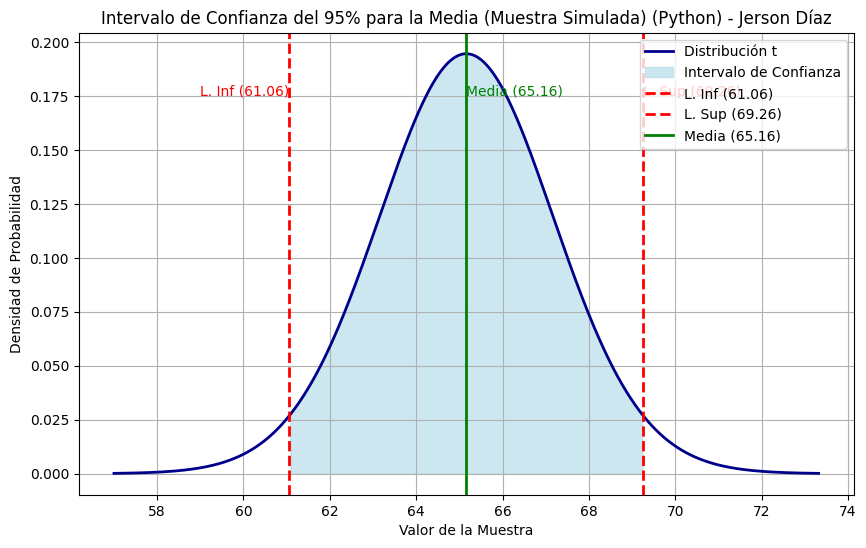

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Fijar la semilla para reproducibilidad (para que la muestra sea la misma que en R)
np.random.seed(123)
muestra = np.random.normal(loc=65, scale=12, size=50)

media_muestra = np.mean(muestra)
s = np.std(muestra, ddof=1) # ddof=1 para desviación estándar muestral
n = len(muestra)
nivel_confianza = 0.95

# Cálculo del error estándar y valor t crítico
error_estandar = s / np.sqrt(n)
t_critico = t.ppf(1 - (1 - nivel_confianza) / 2, df = n - 1)

# Intervalo de confianza
limite_inferior = media_muestra - t_critico * error_estandar
limite_superior = media_muestra + t_critico * error_estandar

print(f"El intervalo de confianza del {nivel_confianza*100:.0f}% para la media de la muestra simulada es: [{limite_inferior:.4f}, {limite_superior:.4f}]")

# Crear una secuencia de valores x para la distribución t
x_t = np.linspace(media_muestra - 4 * error_estandar, media_muestra + 4 * error_estandar, 500)

# Calcular la densidad de probabilidad para cada x usando la distribución t
y_t = t.pdf(x_t, df = n - 1, loc = media_muestra, scale = error_estandar)

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(x_t, y_t, color='darkblue', linewidth=2, label='Distribución t')

# Sombrear el área del intervalo de confianza
x_fill = x_t[(x_t >= limite_inferior) & (x_t <= limite_superior)]
y_fill = y_t[(x_t >= limite_inferior) & (x_t <= limite_superior)]
plt.fill_between(x_fill, 0, y_fill, color='lightblue', alpha=0.6, label='Intervalo de Confianza')

# Añadir líneas verticales para los límites del intervalo y la media
plt.axvline(limite_inferior, color='red', linestyle='--', linewidth=2, label=f'L. Inf ({limite_inferior:.2f})')
plt.axvline(limite_superior, color='red', linestyle='--', linewidth=2, label=f'L. Sup ({limite_superior:.2f})')
plt.axvline(media_muestra, color='green', linestyle='-', linewidth=2, label=f'Media ({media_muestra:.2f})')

# Añadir texto al gráfico
plt.text(media_muestra, np.max(y_t) * 0.9, f'Media ({media_muestra:.2f})', color='green', ha='left')
plt.text(limite_inferior, np.max(y_t) * 0.9, f'L. Inf ({limite_inferior:.2f})', color='red', ha='right')
plt.text(limite_superior, np.max(y_t) * 0.9, f'L. Sup ({limite_superior:.2f})', color='red', ha='left')

plt.xlabel('Valor de la Muestra')
plt.ylabel('Densidad de Probabilidad')
plt.title('Intervalo de Confianza del 95% para la Media (Muestra Simulada) (Python) - Jerson Díaz')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

[⬆️ Volver al inicio](#inicio)